# 🚢 Titanic ML — Advanced Modelling & Hyperparameter Tuning

**Competition:** [Titanic - Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic)  
**Goal:** Predict survival using tuned estimators and ensemble techniques.  
**Target:** Break the ~0.80 cross-validation barrier and generate an optimized ensemble submission.

---

> **Kernel:** Make sure you have selected the `Python (titanic-ml)` kernel before running any cells.
> In VS Code, click the kernel selector in the top-right corner of this notebook.

## 0. ⚙️ Setup & Imports

We load our dependencies, paths, custom `src/` modules, and scikit-learn ensemble classes.

In [1]:
import os
import sys

# Insert project root to path so we can import src modules
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.helpers import load_data, save_submission, display_info, set_seed
from src.preprocessing import clean
from src.features import engineer, select_features
from src.model import build_baseline_model, train_model, predict, cross_validate_model, save_model
from src.tune import grid_search, random_search, get_best_params
from src.evaluate import (
    accuracy_score,
    print_classification_report,
    plot_confusion_matrix,
    plot_feature_importance,
    compare_models,
    roc_auc
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier

set_seed(42)
%matplotlib inline

[seed] Random seed set to 42


## 1. 📂 Load & Clean Data

We load the train and test CSV datasets, clean them, and engineer all the custom features.

In [2]:
train_raw = load_data("../data/train.csv")
test_raw = load_data("../data/test.csv")

print("Preprocessing and engineering features...")
train_clean = clean(engineer(train_raw.copy()))
test_clean = clean(engineer(test_raw.copy()))

feature_cols = select_features(train_clean)
print(f"Selected features ({len(feature_cols)}): {feature_cols}")

X_train = train_clean[feature_cols]
y_train = train_clean["Survived"]
X_test = test_clean[feature_cols]

Preprocessing and engineering features...


Selected features (11): ['Pclass', 'Sex', 'AgeBand', 'FareBand', 'FamilySize', 'IsAlone', 'Title', 'Embarked_Q', 'Embarked_S', 'SibSp', 'Parch']


## 2. 🌲 Tuning Random Forest Classifier

We search the parameter space of the Random Forest classifier using RandomizedSearchCV to optimize tree depths, leaf splits, estimator sizes, and features.

In [3]:
rf = RandomForestClassifier(random_state=42)

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 5, 6, 7, 8],
    'min_samples_split': [4, 8, 12, 16],
    'min_samples_leaf': [2, 4, 6, 8],
    'max_features': ['sqrt', 'log2', None]
}

print("Running Random Forest Random Search...")
rf_search = random_search(rf, param_dist_rf, X_train, y_train, n_iter=20, cv=5)
rf_best = rf_search.best_estimator_

Running Random Forest Random Search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits



[OK] Random search complete (20 iterations).
   Best params : {'n_estimators': 200, 'min_samples_split': 16, 'min_samples_leaf': 6, 'max_features': None, 'max_depth': 8}
   Best score  : 0.8350


## 3. ⚡ Tuning XGBoost Classifier

We tune XGBoost hyperparameters like max depth, subsample ratios, colsample by tree, and learning rates.

In [4]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42, n_jobs=-1)

param_dist_xgb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

print("Running XGBoost Random Search...")
xgb_search = random_search(xgb, param_dist_xgb, X_train, y_train, n_iter=20, cv=5)
xgb_best = xgb_search.best_estimator_

Running XGBoost Random Search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\Users\USER\titanic-ml\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:42:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



[OK] Random search complete (20 iterations).
   Best params : {'subsample': 0.6, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
   Best score  : 0.8350


## 4. 📈 Tuning Gradient Boosting Classifier

We search across the parameters of standard scikit-learn Gradient Boosting.

In [5]:
gb = GradientBoostingClassifier(random_state=42)

param_dist_gb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [4, 8, 12],
    'min_samples_leaf': [2, 4, 6]
}

print("Running Gradient Boosting Random Search...")
gb_search = random_search(gb, param_dist_gb, X_train, y_train, n_iter=20, cv=5)
gb_best = gb_search.best_estimator_

Running Gradient Boosting Random Search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits



[OK] Random search complete (20 iterations).
   Best params : {'n_estimators': 150, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.01}
   Best score  : 0.8328


## 5. 🤝 Soft Voting Ensemble Classifier

We combine our three beautifully tuned estimators into a single soft `VotingClassifier`. Soft voting averages the class probabilities predicted by each model to get robust predictions.

In [6]:
voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf_best),
        ('xgb', xgb_best),
        ('gb', gb_best)
    ],
    voting='soft'
)

print("Evaluating Voting Ensemble...")
voting_cv = cross_validate_model(voting_clf, X_train, y_train, cv=5)
voting_clf = train_model(voting_clf, X_train, y_train)

Evaluating Voting Ensemble...


  CV 5-fold accuracy: 0.8305 ± 0.0123
  Individual folds: ['0.8492', '0.8146', '0.8202', '0.8315', '0.8371']


C:\Users\USER\titanic-ml\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:42:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 6. ⚖️ Comparison of Tuned Models & Ensemble

Let's compare the cross-validation accuracies of all tuned models alongside our soft voting ensemble.

Plotting Model Comparison...


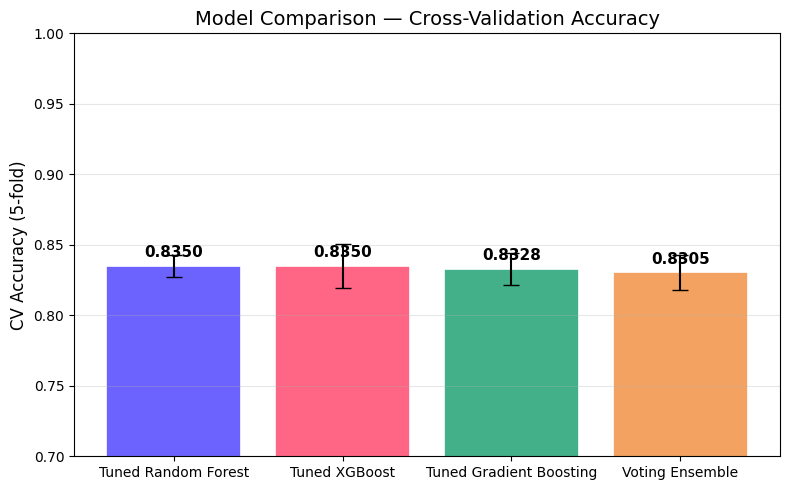

In [7]:
comparison_results = {
    "Tuned Random Forest": {
        "mean": rf_search.best_score_,
        "std": rf_search.cv_results_['std_test_score'][rf_search.best_index_]
    },
    "Tuned XGBoost": {
        "mean": xgb_search.best_score_,
        "std": xgb_search.cv_results_['std_test_score'][xgb_search.best_index_]
    },
    "Tuned Gradient Boosting": {
        "mean": gb_search.best_score_,
        "std": gb_search.cv_results_['std_test_score'][gb_search.best_index_]
    },
    "Voting Ensemble": voting_cv
}

print("Plotting Model Comparison...")
compare_models(comparison_results, save=False)

## 7. 💾 Generate Optimized Ensemble Submission

We generate survival predictions on the test set using our soft voting ensemble classifier, and save them for Kaggle submission.

In [8]:
print("Generating final ensemble predictions...")
y_test_pred = predict(voting_clf, X_test)

# Prepare submission dataframe
submission = pd.DataFrame({
    "PassengerId": test_raw["PassengerId"],
    "Survived": y_test_pred.astype(int)
})

# Save submission file
save_submission(submission, "../submissions/tuned_ensemble_submission_v2.csv")

Generating final ensemble predictions...
[OK] Submission saved -> ../submissions/tuned_ensemble_submission_v2.csv  (418 rows)
